# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Telco Customer Churn (IBM Dataset)**. Dataset ini memiliki 7.043 baris dan 33 kolom. Target klasifikasi adalah `Churn Value` (1 = Churn, 0 = Retained) untuk memprediksi apakah seorang pelanggan akan berhenti menggunakan layanan telekomunikasi atau tidak.

# **2. Import Library**

Kita mengimpor beberapa pustaka utama seperti pandas, numpy, matplotlib, seaborn, dan scikit-learn.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

print("Library successfully imported!")

Library successfully imported!


# **3. Memuat Dataset**

Memuat dataset dari folder `namadataset_raw`.

In [2]:
raw_path = '../namadataset_raw/Telco_customer_churn_raw.xlsx'
df = pd.read_excel(raw_path)
print(f"Shape of dataset: {df.shape}")
df.head()

Shape of dataset: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# **4. Exploratory Data Analysis (EDA)**

Melakukan EDA untuk memahami karakteristik dataset.

In [3]:
# Info dataset
df.info()

# Statistik deskriptif
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [4]:
# Memeriksa missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
Churn Reason    5174
dtype: int64


C:\Users\mfala\AppData\Local\Temp\ipykernel_20316\849517505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn Value', data=df, palette='viridis')


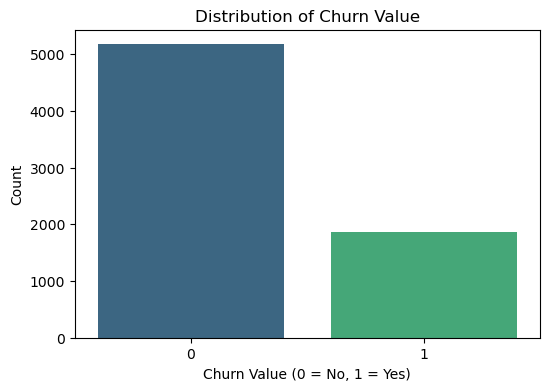

In [5]:
# Distribusi Target (Churn Value)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn Value', data=df, palette='viridis')
plt.title('Distribution of Churn Value')
plt.xlabel('Churn Value (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

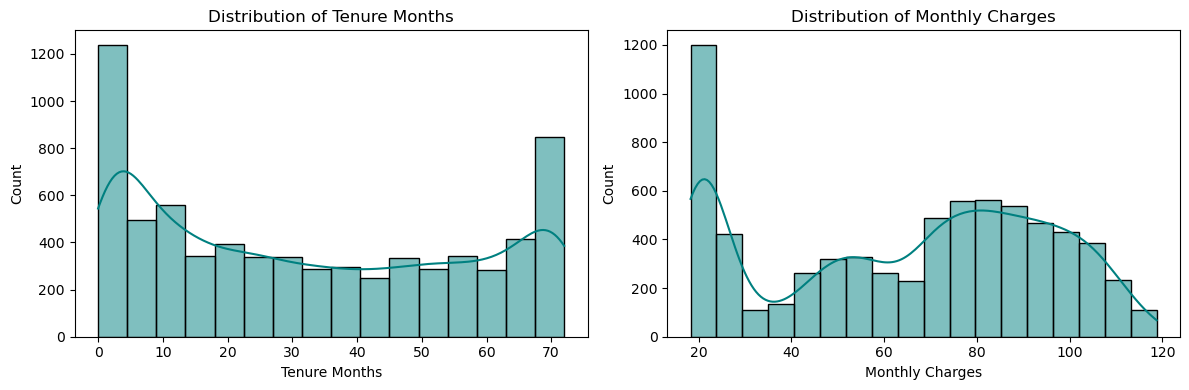

In [6]:
# Distribusi fitur numerik utama
num_cols = ['Tenure Months', 'Monthly Charges']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Langkah-langkah preprocessing meliputi:
1. Pembersihan kolom `Total Charges` (mengubah string kosong menjadi 0 dan tipe data menjadi float).
2. Menghapus kolom yang tidak relevan atau yang menyebabkan data leakage (seperti `CustomerID`, `Count`, `Country`, `State`, `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude`, `Churn Label`, `Churn Score`, `CLTV`, `Churn Reason`).
3. Encoding variabel kategorikal.
4. Normalisasi/Scaling data numerik.

In [7]:
# 1. Clean Total Charges
df['Total Charges'] = df['Total Charges'].astype(str).str.strip()
df['Total Charges'] = df['Total Charges'].replace('', '0')
df['Total Charges'] = pd.to_numeric(df['Total Charges'])
print("Total Charges dtype:", df['Total Charges'].dtype)

Total Charges dtype: float64


In [8]:
# 2. Drop columns
cols_to_drop = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 
    'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 
    'Churn Score', 'CLTV', 'Churn Reason'
]
df_clean = df.drop(columns=cols_to_drop)
print(f"Shape after dropping columns: {df_clean.shape}")

Shape after dropping columns: (7043, 20)


In [9]:
# 3. Encoding dan Scaling
# Identifikasi kolom kategorikal dan numerik
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

# One-Hot Encoding
df_preprocessed = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dtype=int)

# Scaling numerical features
scaler = StandardScaler()
df_preprocessed[num_cols] = scaler.fit_transform(df_preprocessed[num_cols])

print(f"Shape of preprocessed dataset: {df_preprocessed.shape}")
df_preprocessed.head()

Shape of preprocessed dataset: (7043, 31)


,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,-1.236724,-0.362660,-0.958066,1,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
1,-1.236724,0.197365,-0.938874,1,0,0,0,1,1,0,...,0,0,0,0,0,0,1,0,1,0
2,-0.992402,1.159546,-0.643789,1,0,0,0,1,1,0,...,0,1,0,1,0,0,1,0,1,0
3,-0.177995,1.330711,0.338085,1,0,0,1,1,1,0,...,0,1,0,1,0,0,1,0,1,0
4,0.677133,1.294151,1.216150,1,1,0,0,1,1,0,...,0,1,0,1,0,0,1,0,0,0


In [10]:
# 4. Simpan dataset preprocessing
output_dir = './namadataset_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Telco_customer_churn_preprocessing.csv')
df_preprocessed.to_csv(output_path, index=False)
print(f"Preprocessed data successfully saved to: {output_path}")

Preprocessed data successfully saved to: ./namadataset_preprocessing\Telco_customer_churn_preprocessing.csv
